# 02 — Class Distribution

Analyzes class balance across primary (accident type) and secondary label dimensions.

**Analyzer:** `ClassAnalyzer`  
**Outputs:** `class_distribution_report.md`, `summary.json`, `class_distribution.csv`, `secondary_label_distributions.csv`

## Setup

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "02_class_distribution"
START_TIME = time.time()

from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine, CATEGORICAL_COLOURS, DATASET_COLOURS
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import ClassAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)
snap_start = monitor.snapshot("start")
logger.log_start()

[22:13:46] INFO     ═══ EDA START: 02_class_distribution ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [2]:
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)
logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: Currently logged in as: saksham4data (saksham4data-vinkura) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Tracking run with wandb version 0.28.1


wandb: Run data is saved locally in E:\Rads\eda\notebooks\wandb\run-20260801_221350-ymshgy3e
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run eda-02_class_distribution


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/ymshgy3e


[22:13:52] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


## Analysis

In [3]:
analyzer = ClassAnalyzer(df, config)
results = analyzer.analyze()

# Primary label summary
primary = results["primary_label"]
if primary.get("available"):
    print(f"Primary label: {primary['column']}")
    print(f"Unique classes: {primary['unique_classes']}")
    print(f"Imbalance ratio: {primary['imbalance_ratio']:.2f}")
    print(f"Entropy: {primary['entropy']:.4f} bits")
    print(f"\nDistribution:")
    for cls, count in sorted(primary["distribution"].items(), key=lambda x: -x[1]):
        pct = primary["percentages"][cls]
        print(f"  {cls}: {count:,} ({pct:.1f}%)")

# Secondary labels
print("\n── Secondary Labels ──")
for label, info in results["secondary_labels"].items():
    if info.get("available"):
        print(f"  {label}: {info['unique_values']} unique values")

Primary label: type
Unique classes: 8
Imbalance ratio: 66.00
Entropy: 2.7763 bits

Distribution:
  rear-end: 1,122 (21.0%)
  t-bone: 1,015 (19.0%)
  single: 746 (14.0%)
  head-on: 705 (13.2%)
  sideswipe: 650 (12.2%)
  non-accident: 577 (10.8%)
  accident: 506 (9.5%)
  challenging: 17 (0.3%)

── Secondary Labels ──
  weather: 9 unique values
  day_time: 3 unique values
  scene_layout: 9 unique values
  quality: 6 unique values


## Visualisation

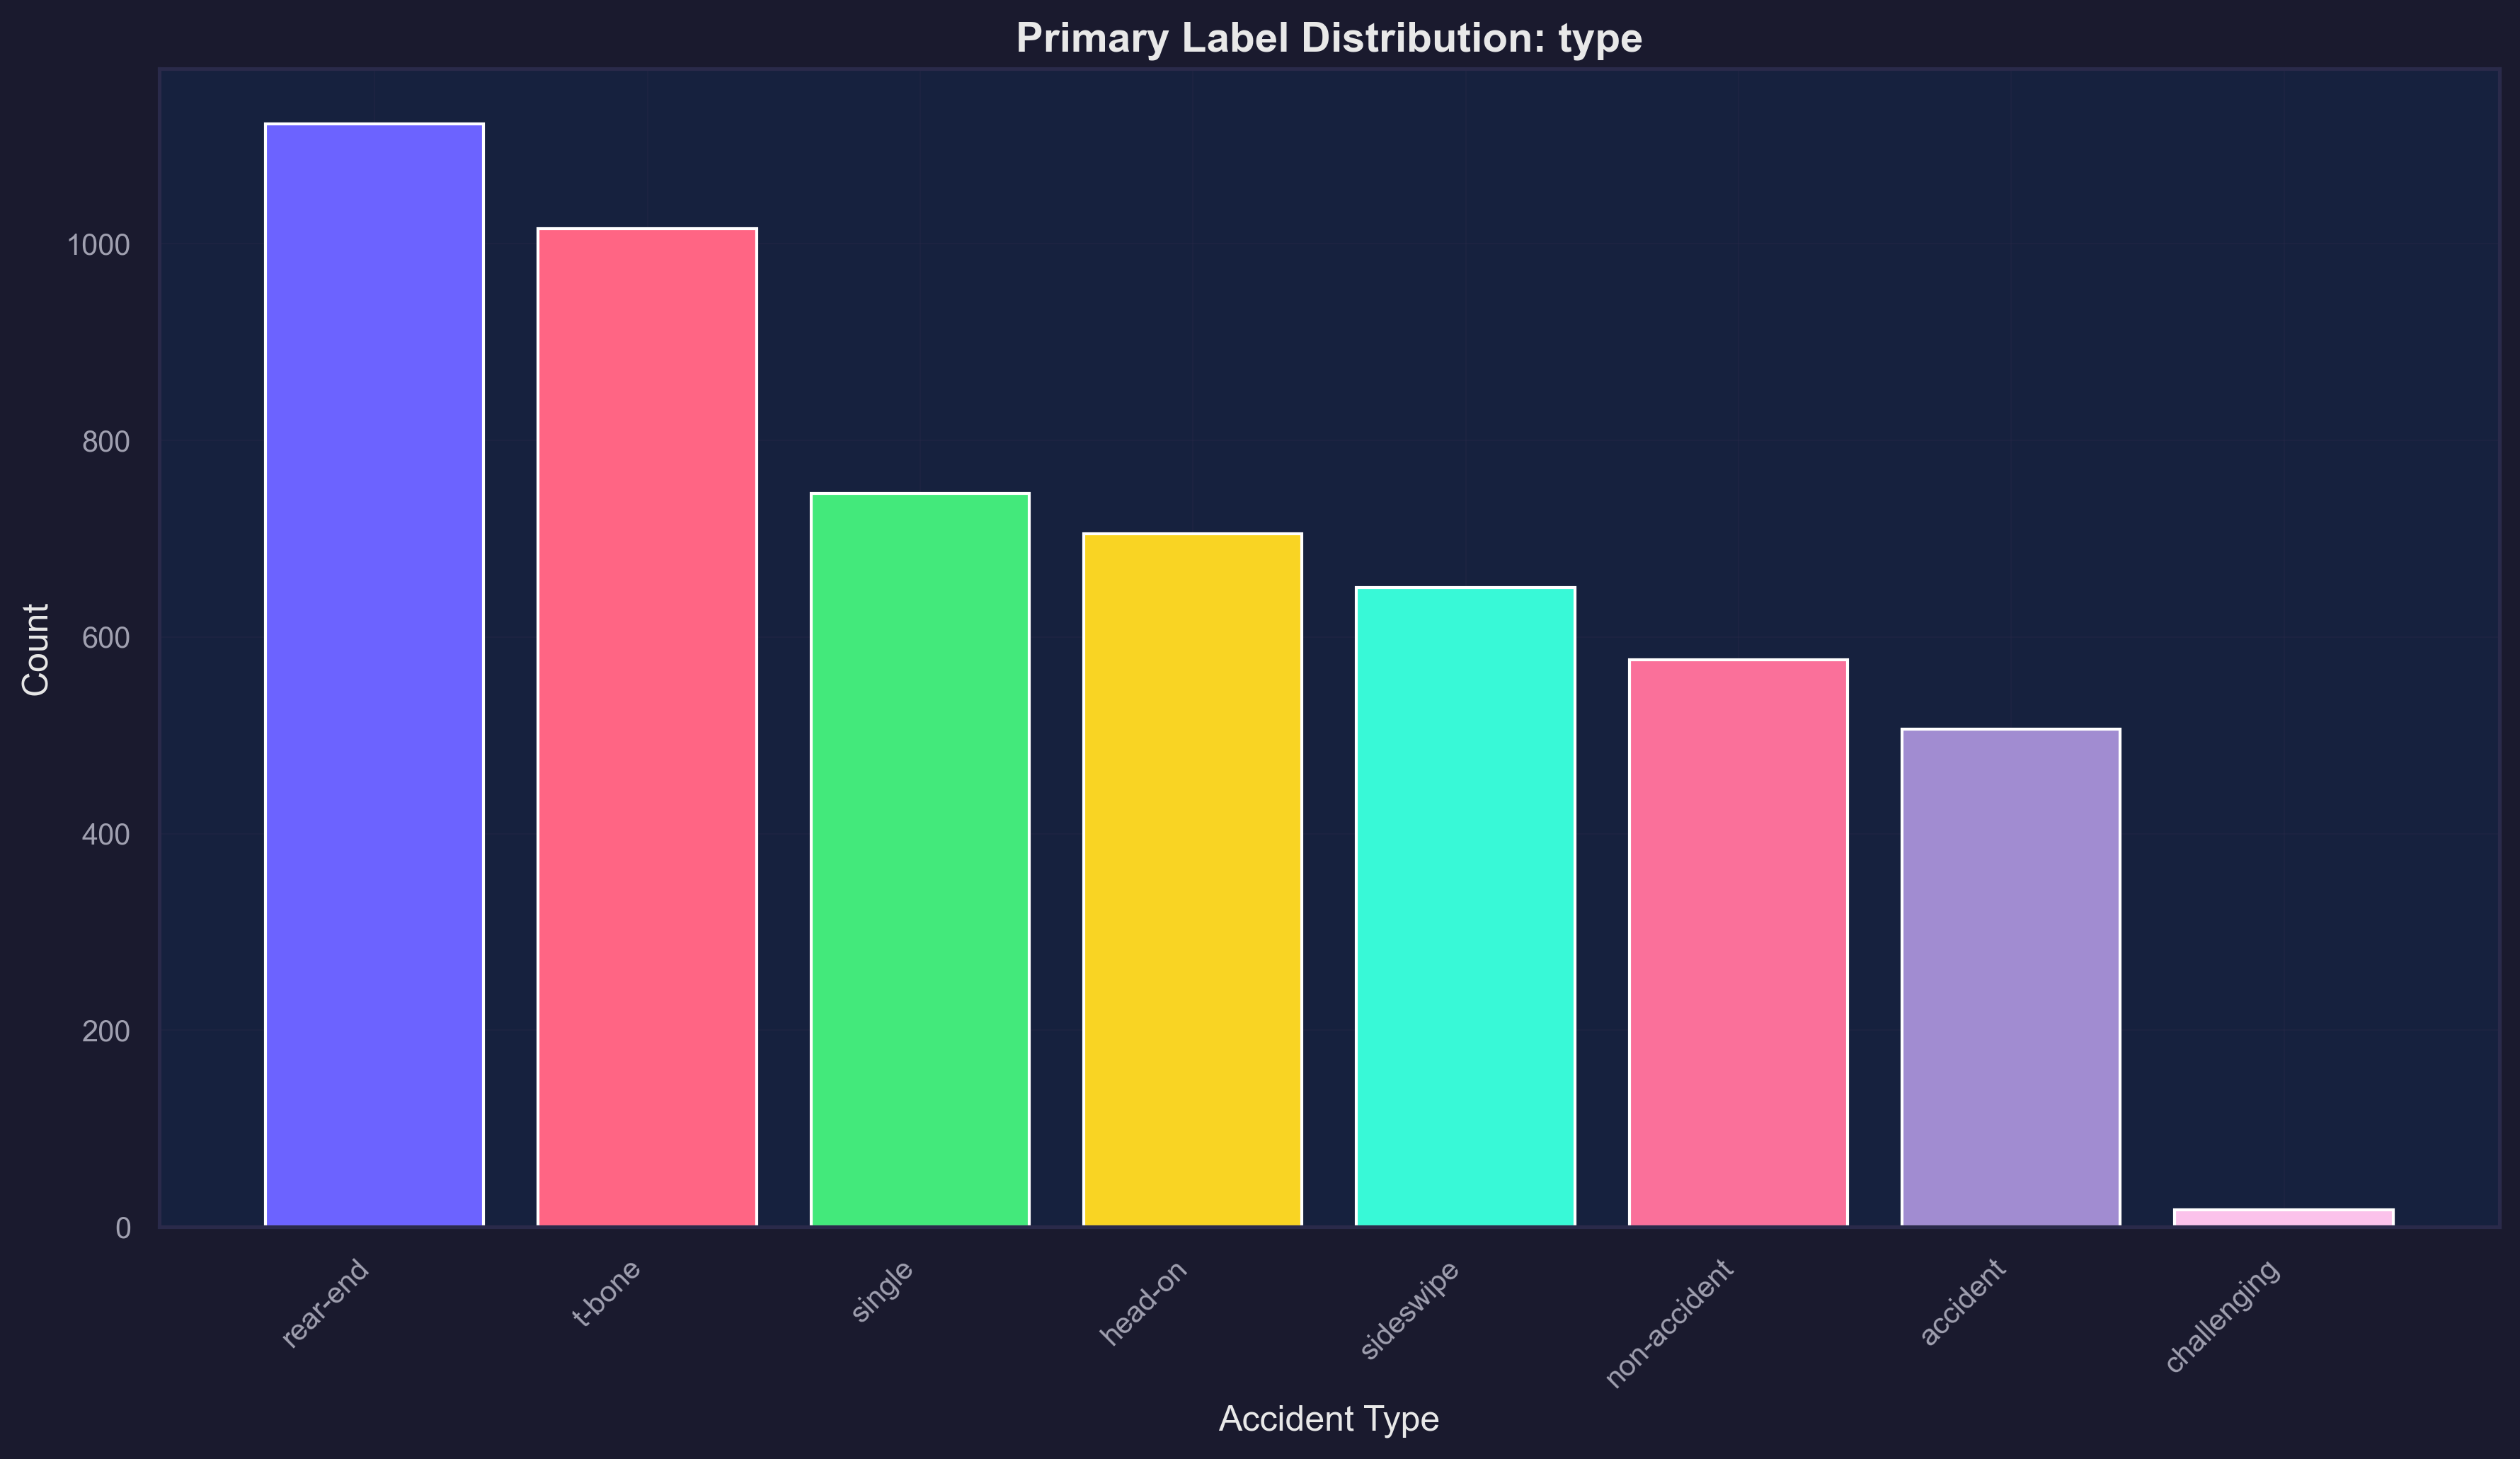

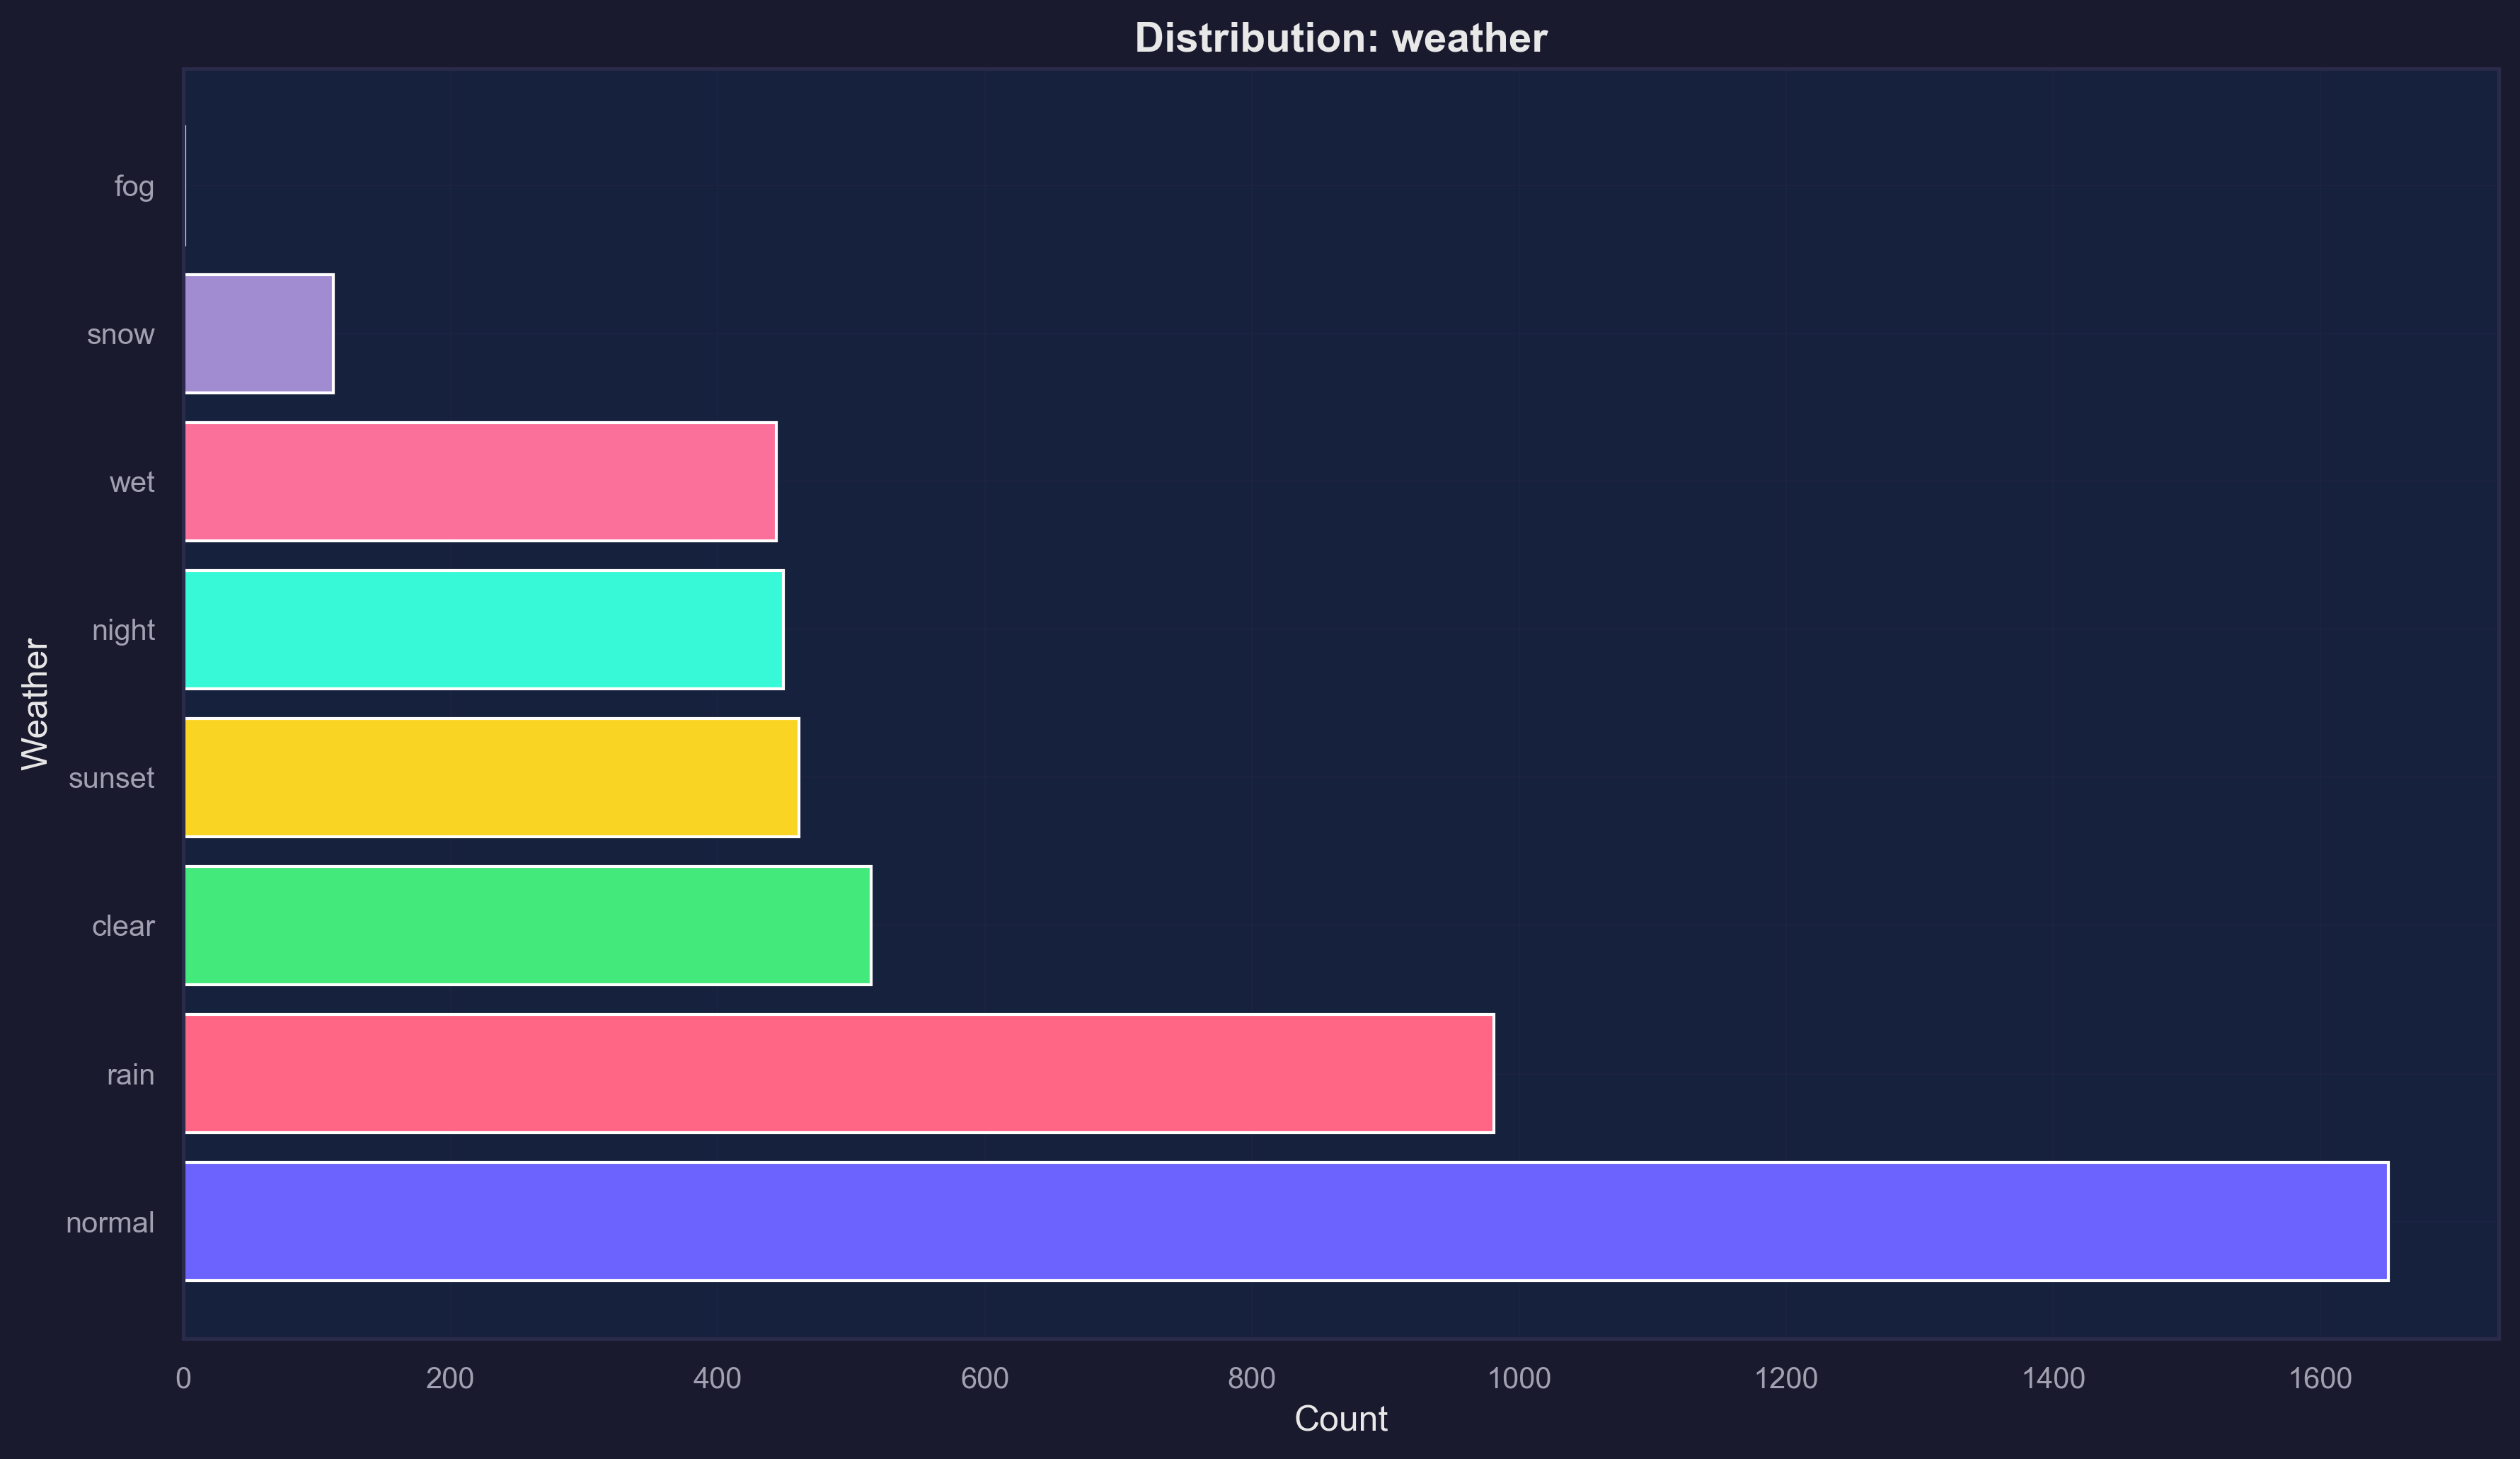

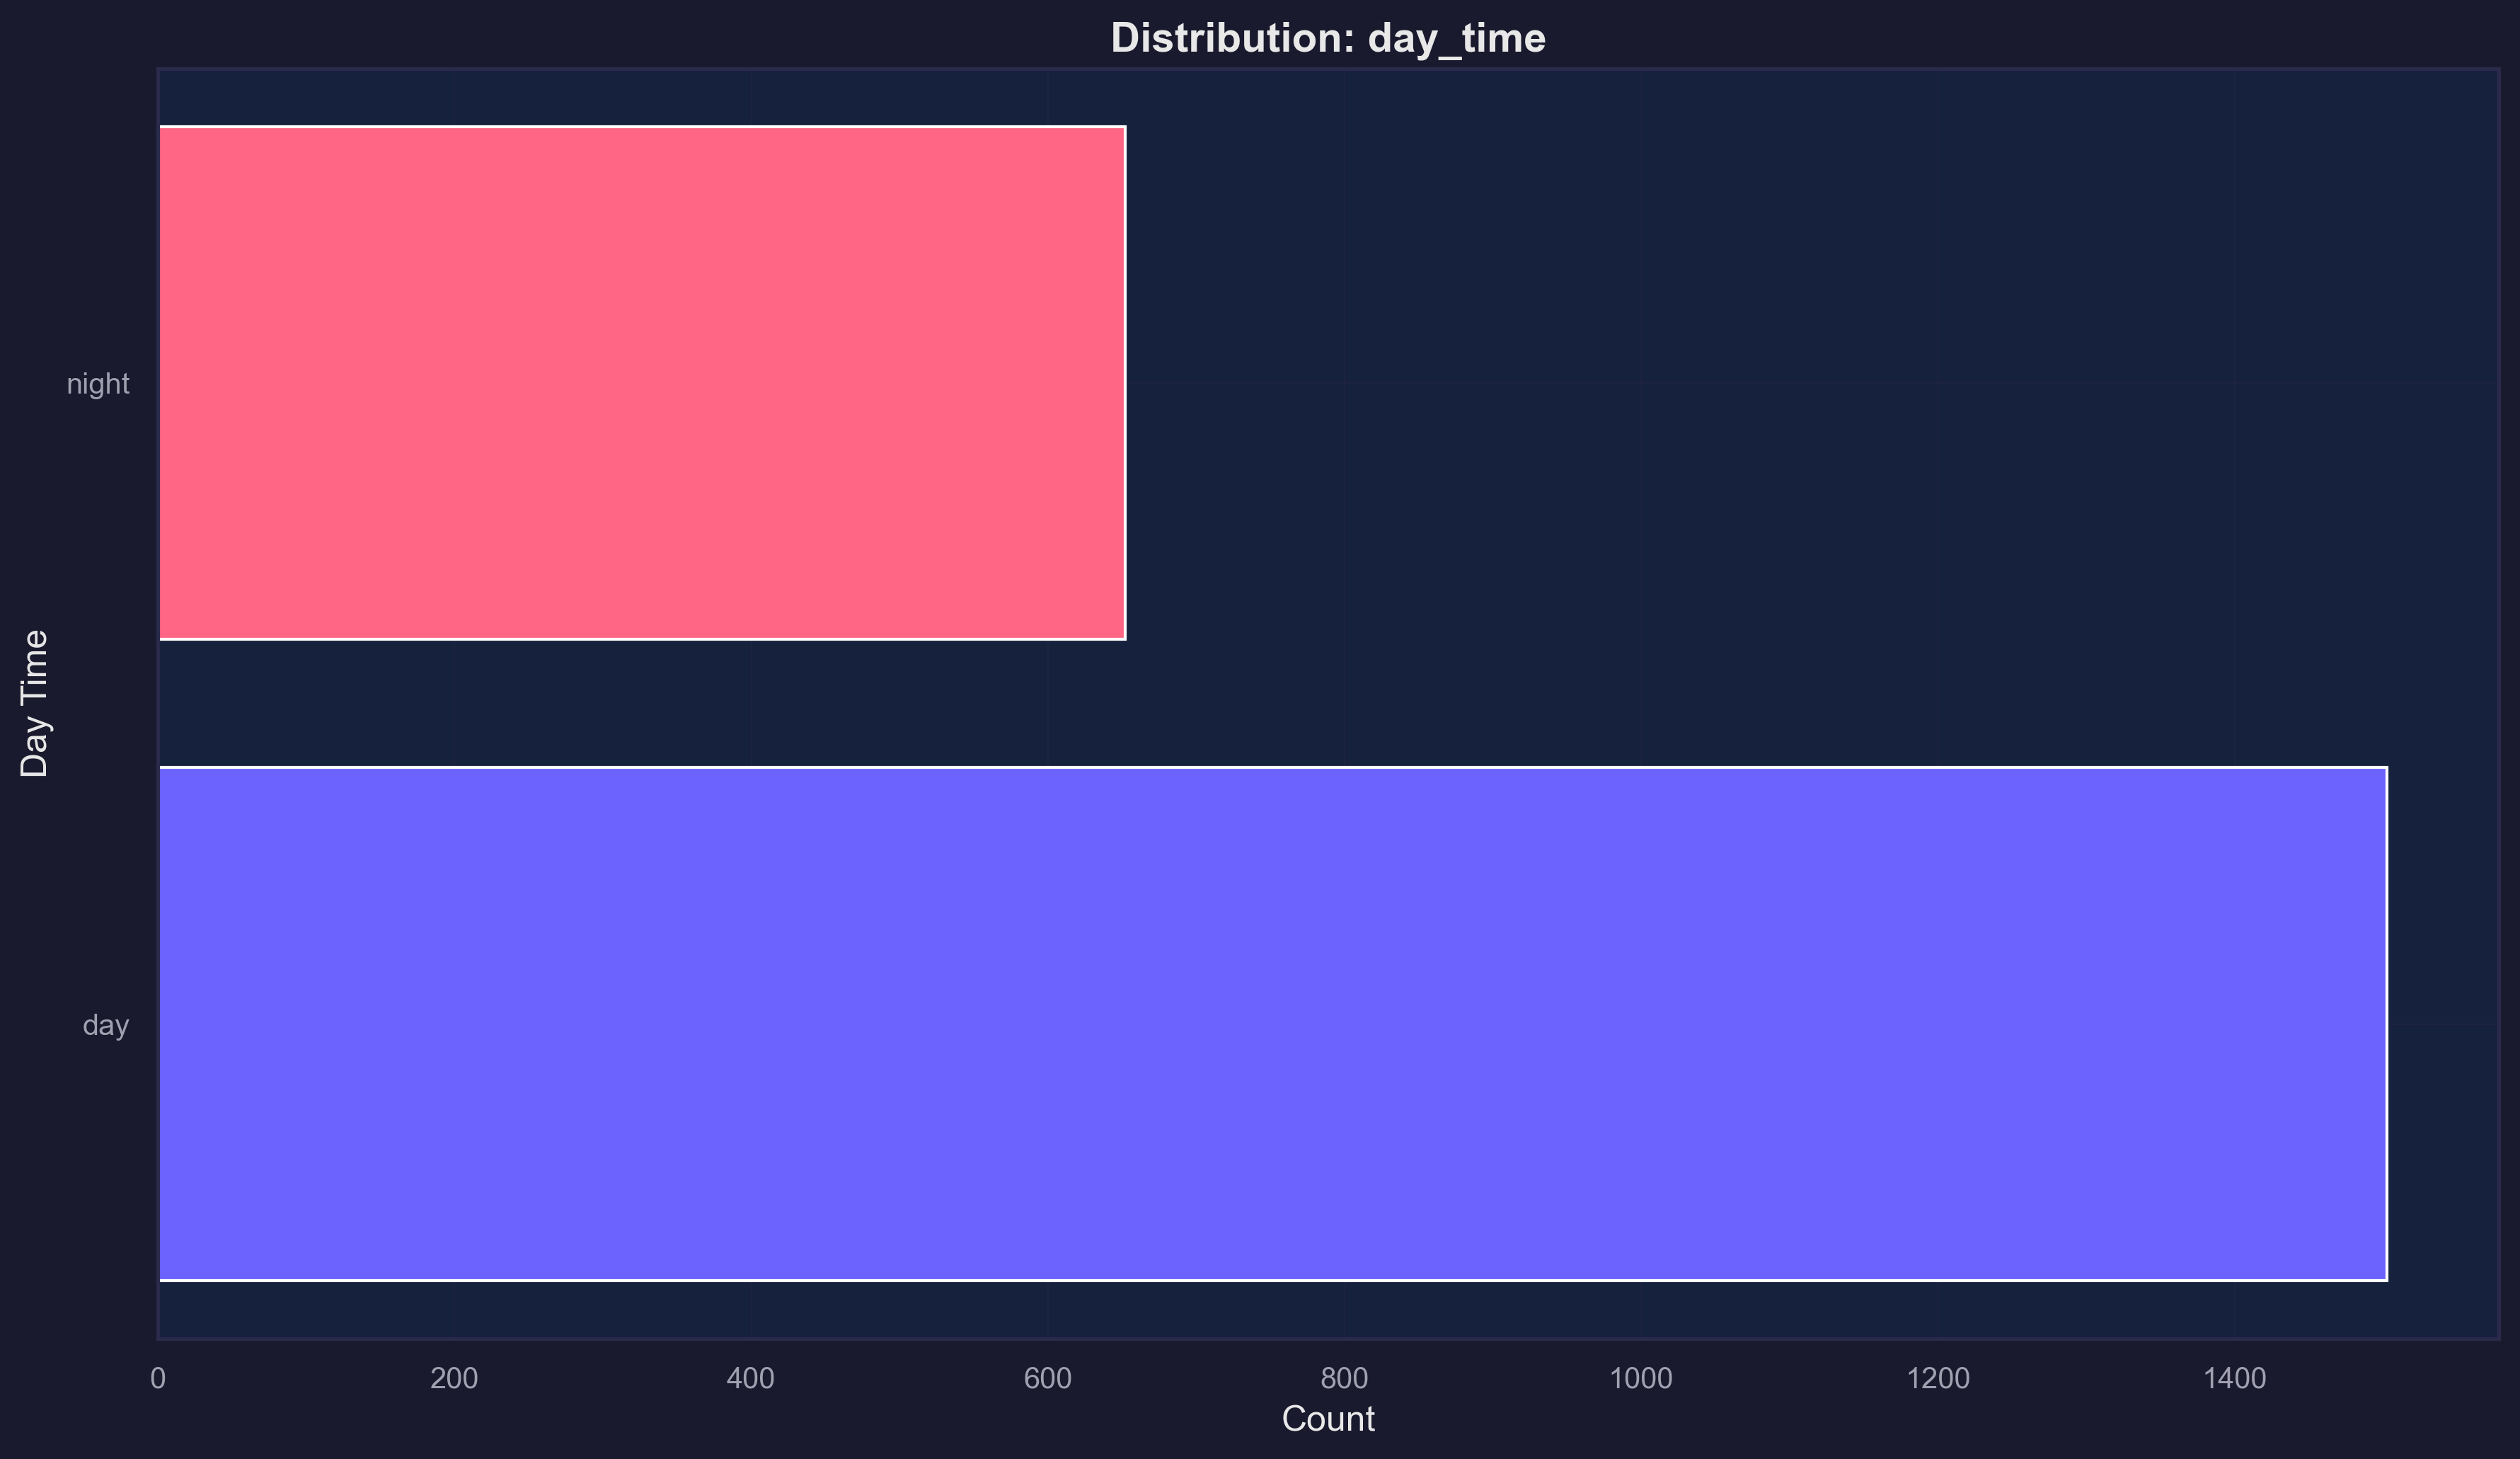

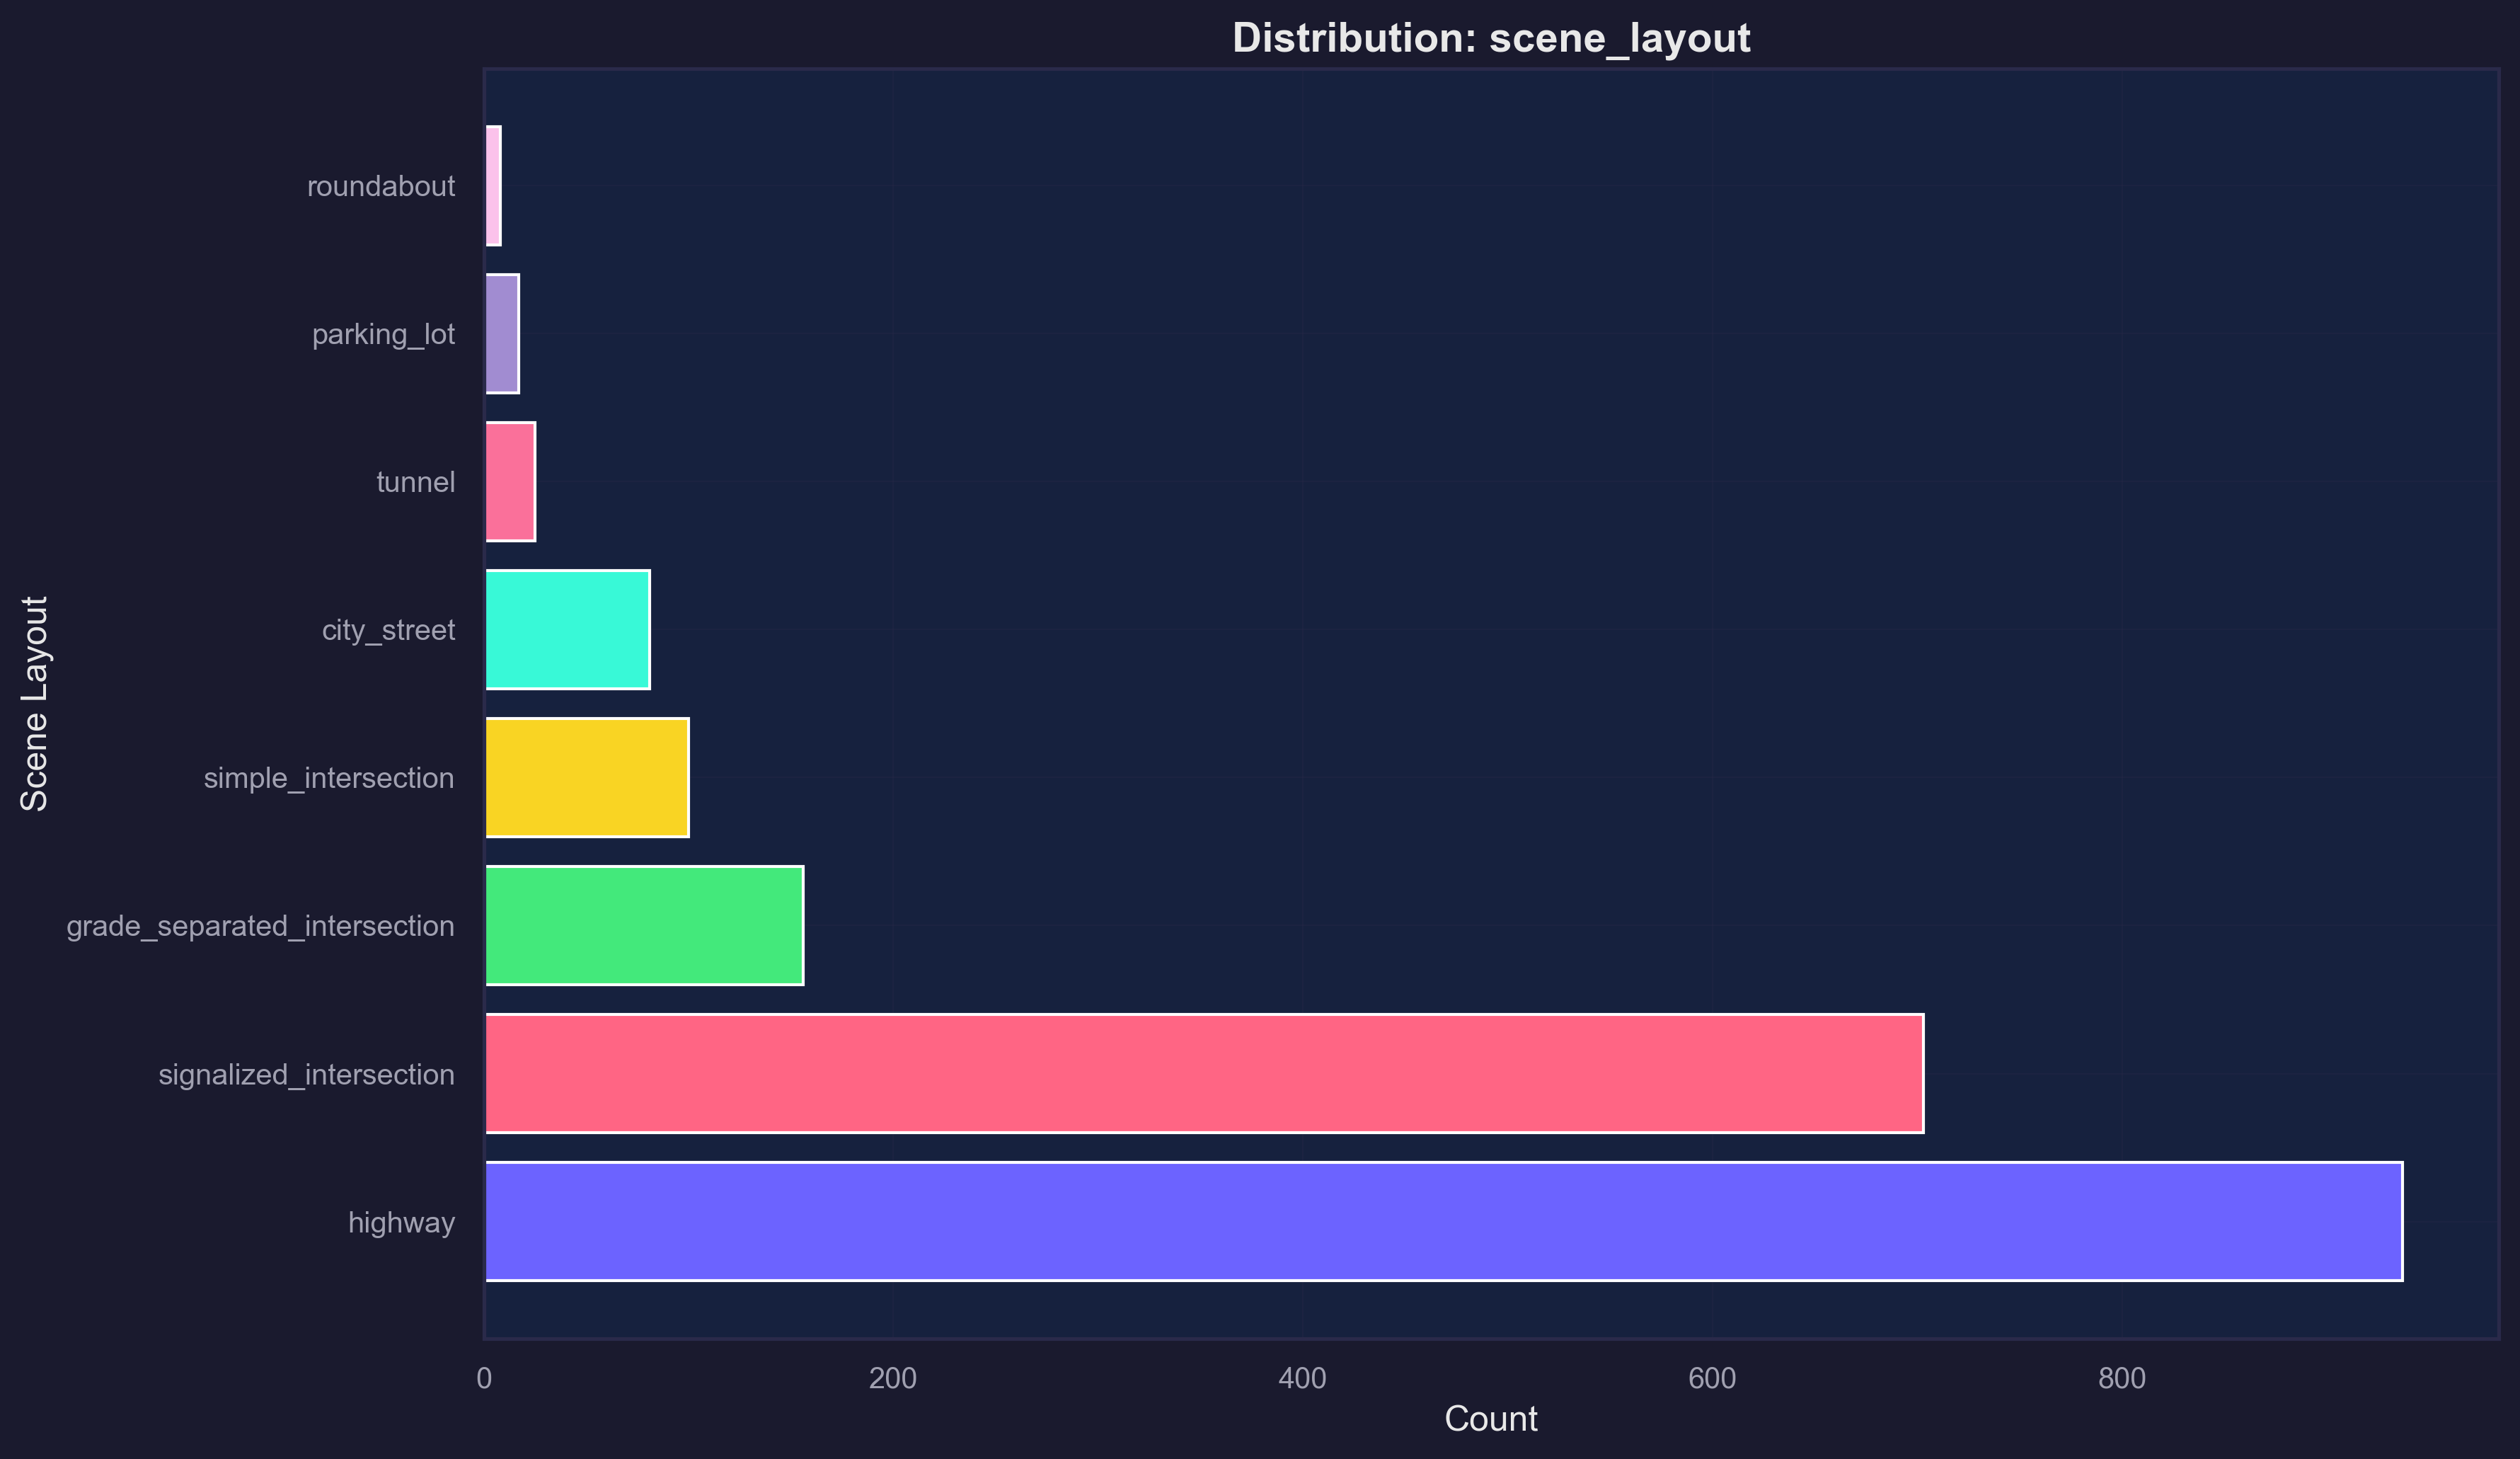

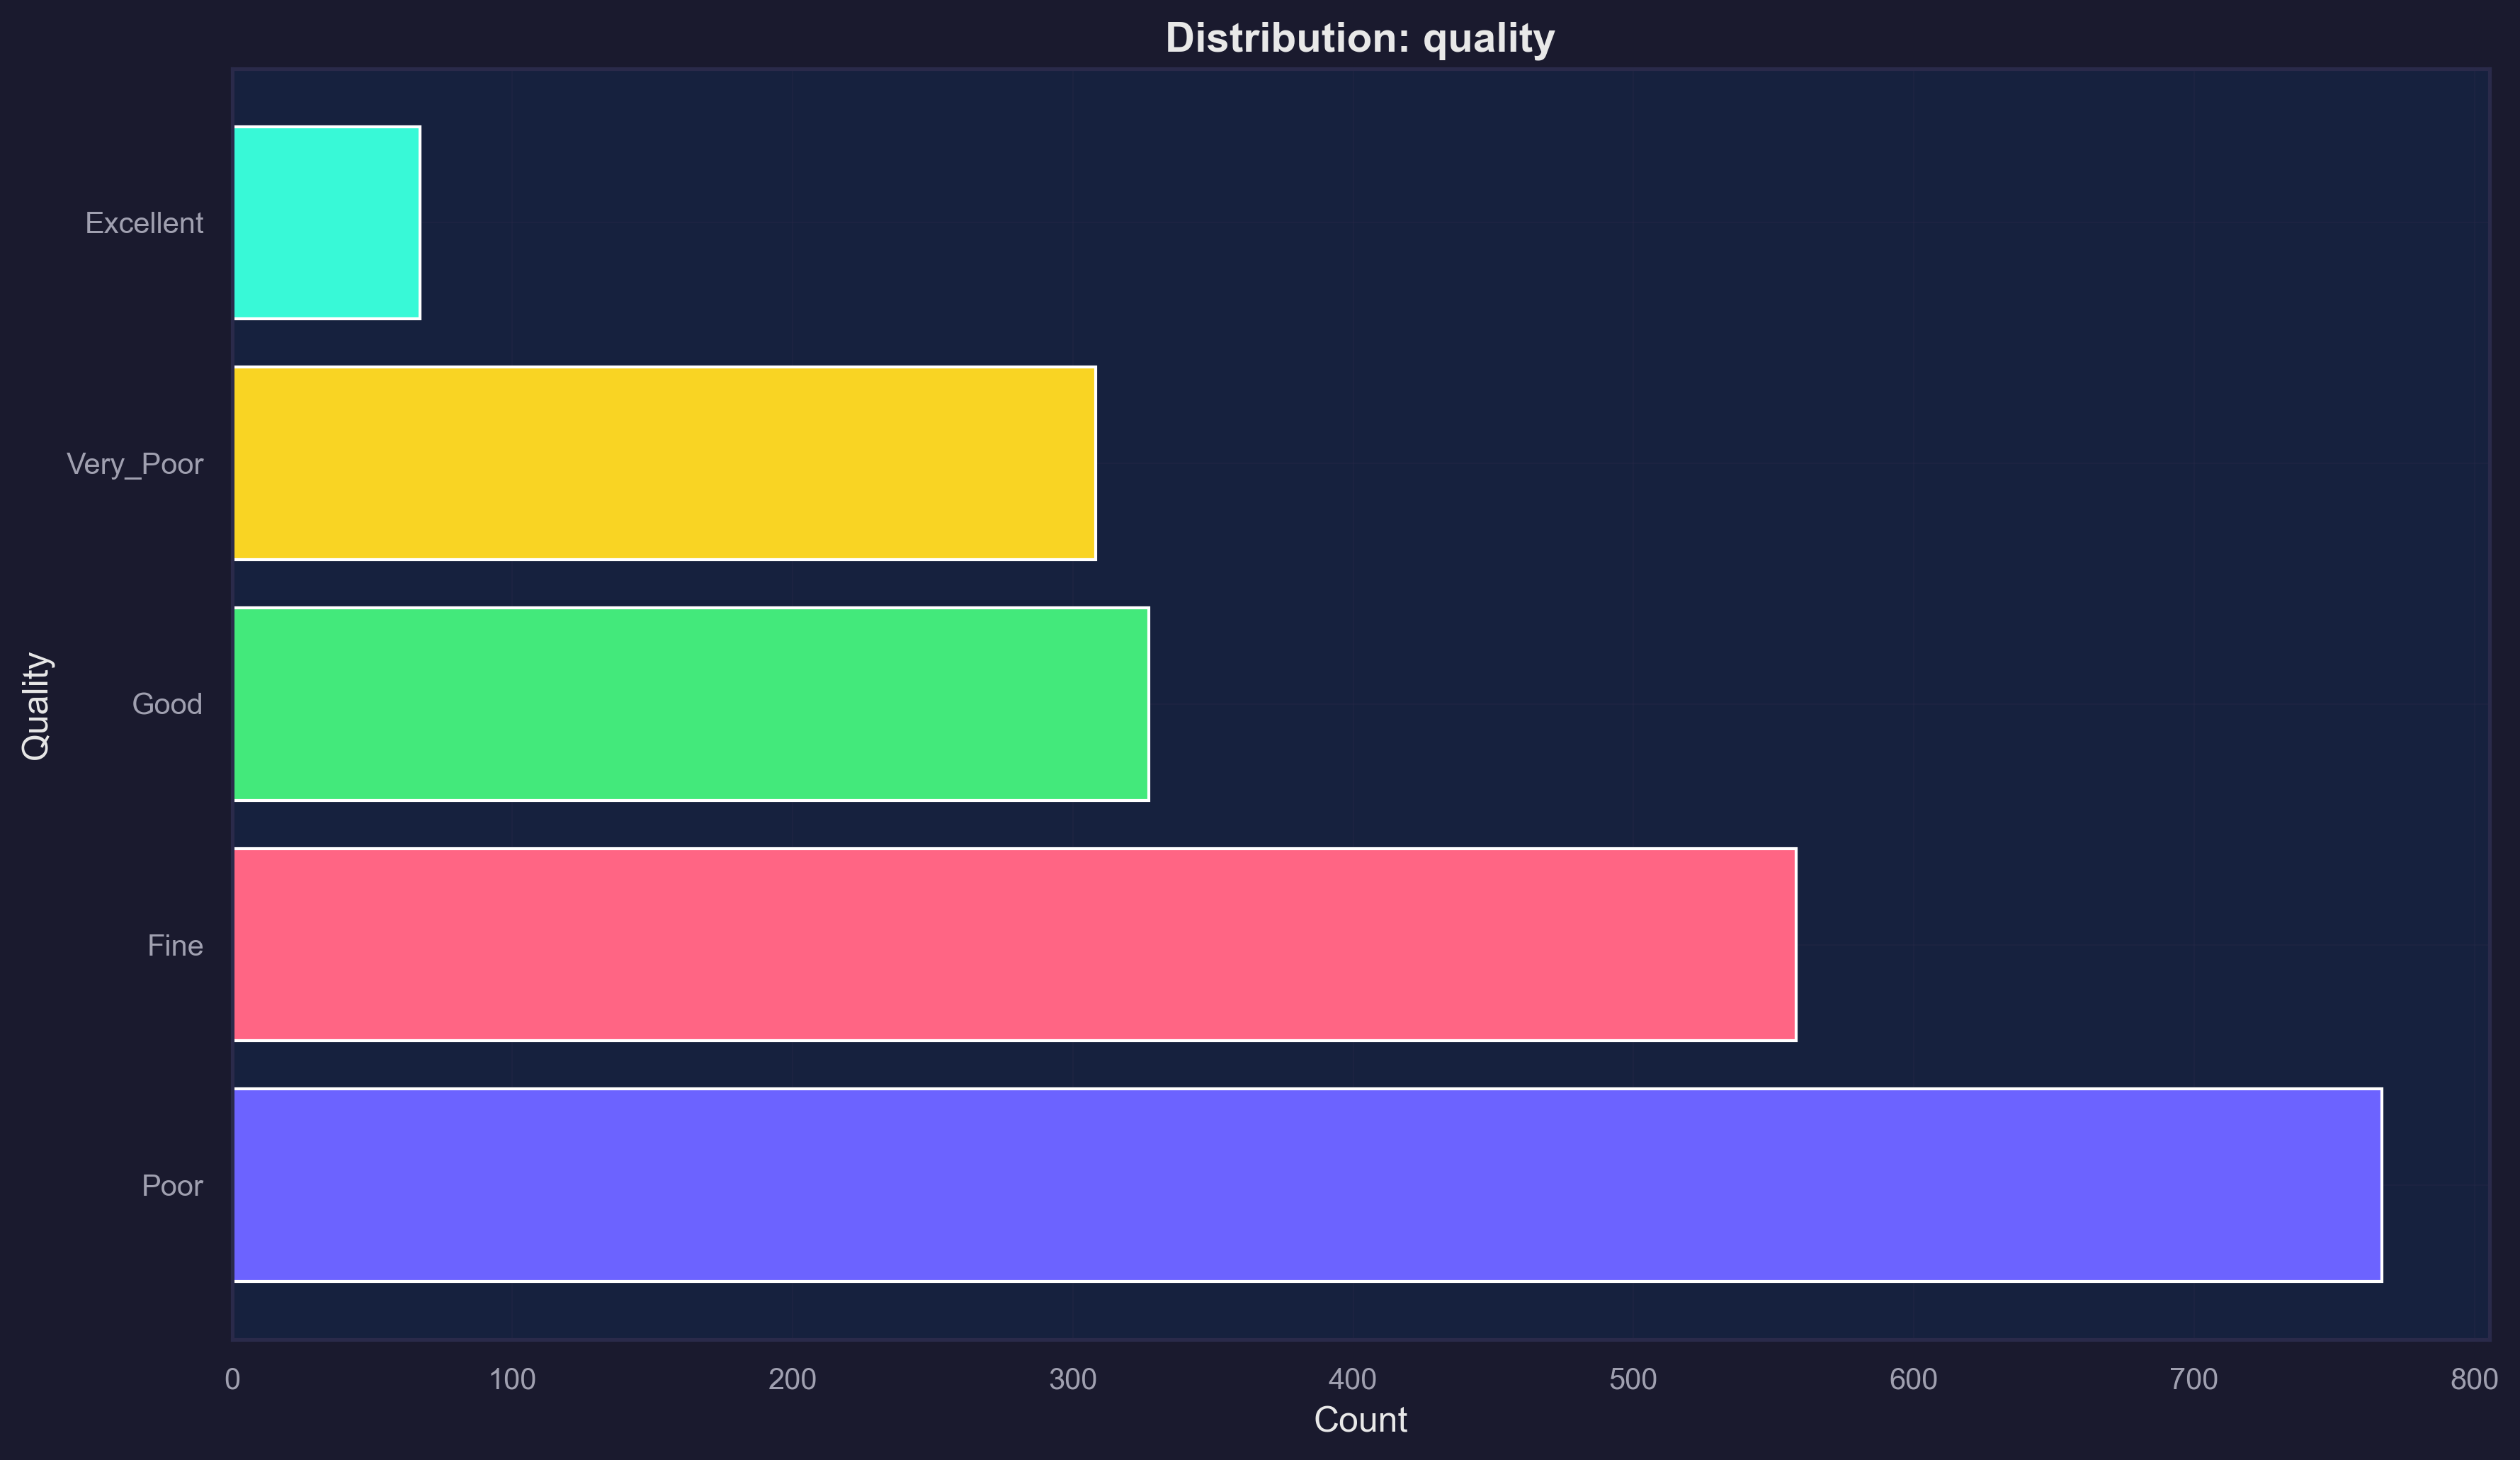

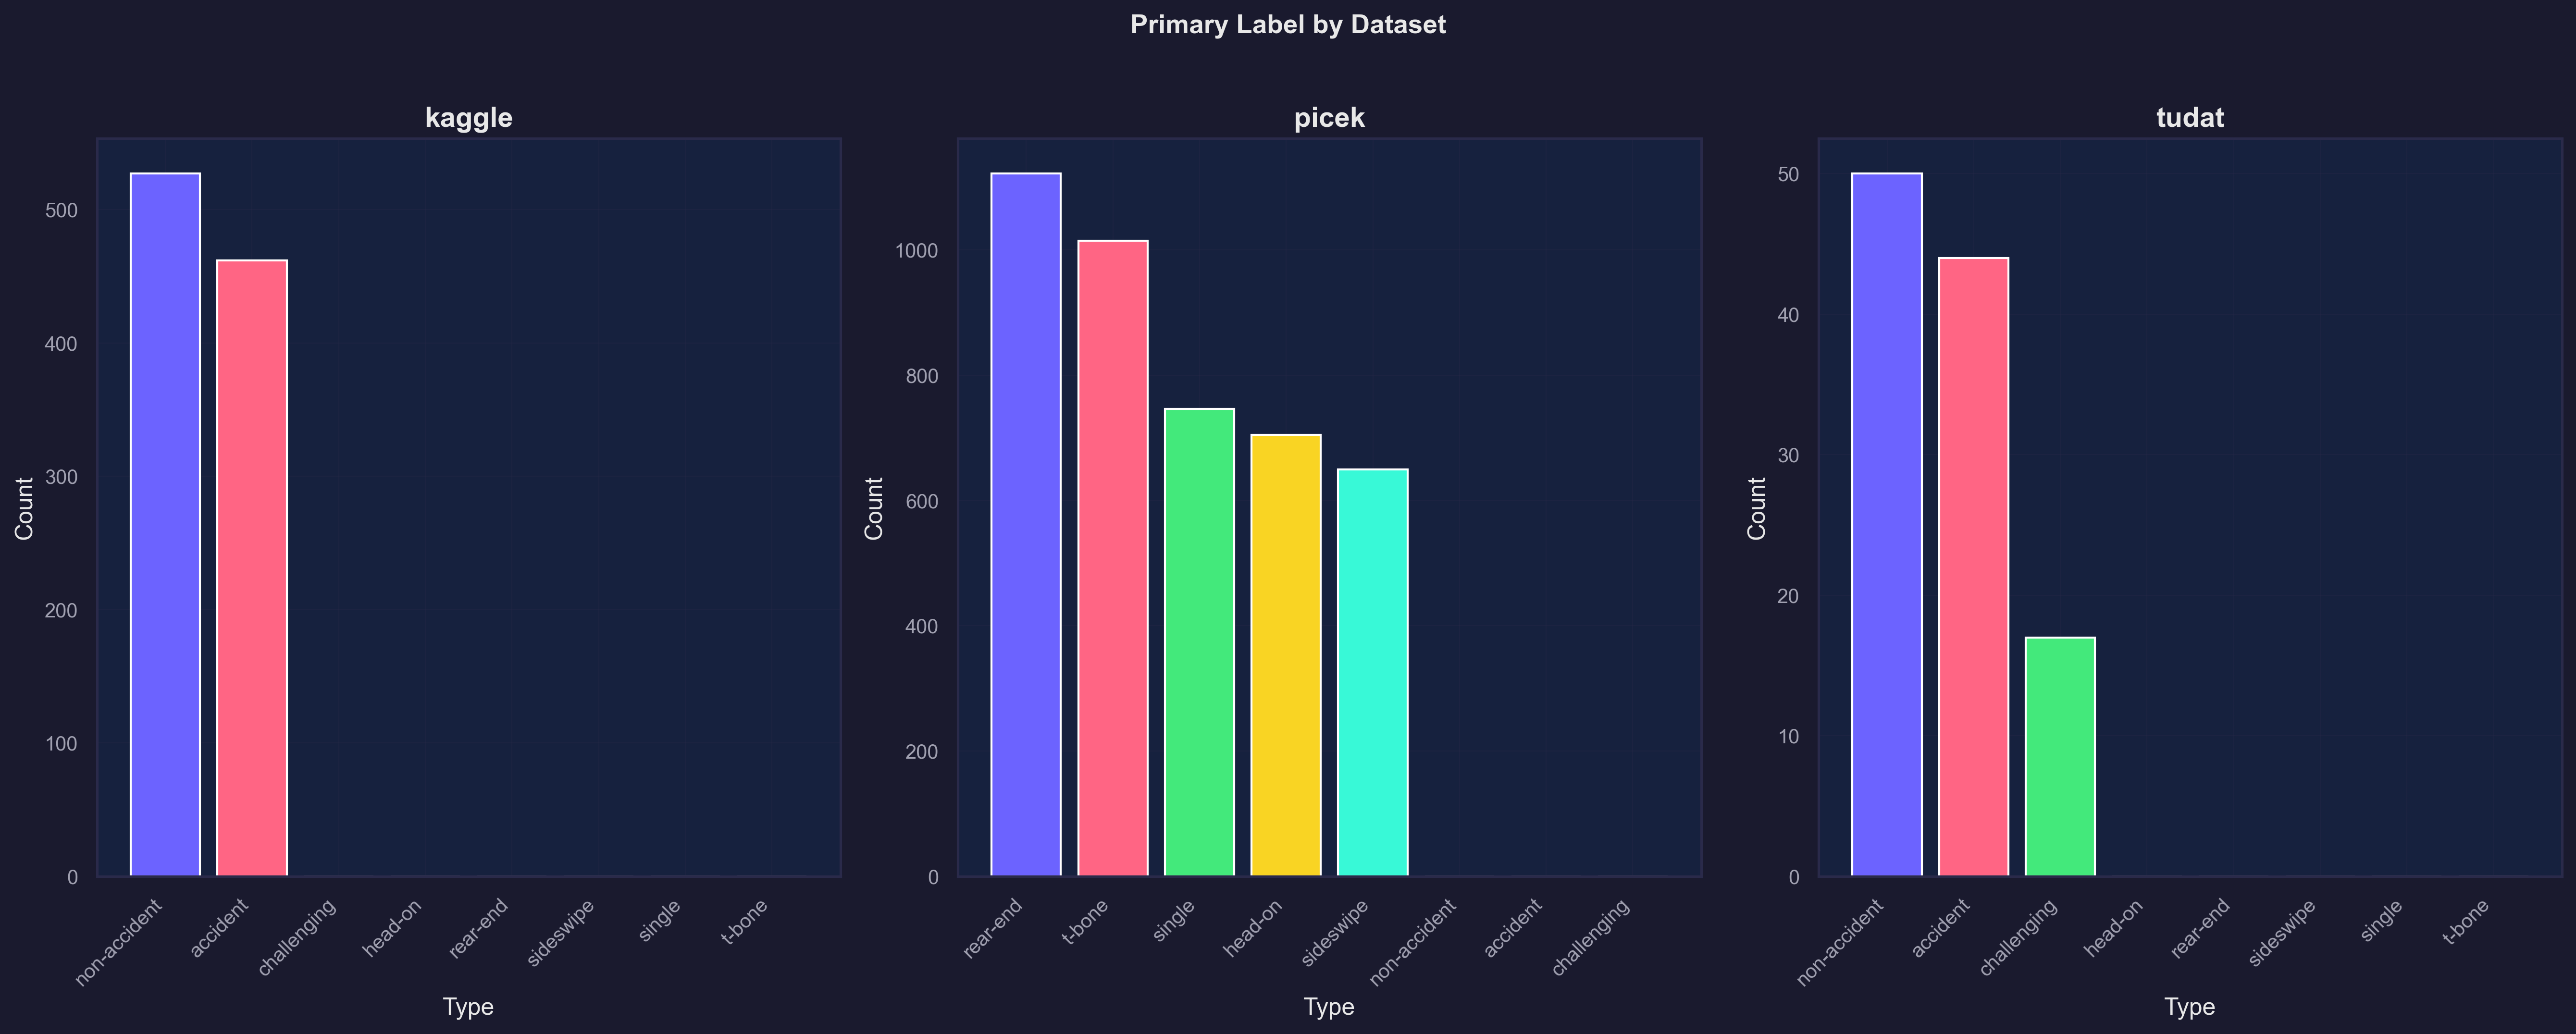

In [4]:
# Primary label distribution
if primary.get("available"):
    fig, ax = plot_engine.create_figure(figsize=(12, 7))
    plot_engine.plot_bar_chart(
        df[config.primary_label].dropna(),
        title=f"Primary Label Distribution: {config.primary_label}",
        xlabel="Accident Type",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "primary_label_distribution")
    wb.log_figure(fig, "primary_label_distribution")
    plt.show()

# Secondary label plots
for label in config.secondary_labels:
    if label in df.columns and df[label].notna().any():
        fig, ax = plot_engine.create_figure(figsize=(12, 7))
        plot_engine.plot_bar_chart(
            df[label].dropna(),
            title=f"Distribution: {label}",
            xlabel=label.replace("_", " ").title(),
            horizontal=True,
            ax=ax,
        )
        plt.tight_layout()
        output.save_figure(fig, f"{label}_distribution")
        wb.log_figure(fig, f"{label}_distribution")
        plt.show()

# Per-dataset primary label
datasets = analyzer.iter_datasets()
if len(datasets) > 1 and primary.get("available"):
    fig, axes = plot_engine.create_figure(
        nrows=1, ncols=len(datasets),
        figsize=(6 * len(datasets), 7),
    )
    if len(datasets) == 1:
        axes = [axes]
    for ax, ds in zip(axes, datasets):
        ds_df = df[df["dataset_name"] == ds]
        if not ds_df[config.primary_label].dropna().empty:
            plot_engine.plot_bar_chart(
                ds_df[config.primary_label].dropna(),
                title=f"{ds}",
                xlabel="Type",
                ax=ax,
            )
    fig.suptitle("Primary Label by Dataset", fontweight="bold", y=1.02)
    plt.tight_layout()
    output.save_figure(fig, "primary_label_per_dataset")
    wb.log_figure(fig, "primary_label_per_dataset")
    plt.show()

## Report & Export

In [5]:
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)
rg.add_heading("Primary Label Distribution")
if primary.get("available"):
    dist_df = pd.DataFrame([
        {"class": k, "count": v, "percent": primary["percentages"][k]}
        for k, v in primary["distribution"].items()
    ]).sort_values("count", ascending=False)
    rg.add_table(dist_df, key="primary_distribution")
    rg.add_stats({
        "unique_classes": primary["unique_classes"],
        "imbalance_ratio": primary["imbalance_ratio"],
        "entropy": primary["entropy"],
        "class_imbalance_score": results["quality_components"]["class_imbalance_score"],
    })
    output.save_csv(dist_df, "class_distribution")

# Secondary labels export
sec_rows = []
for label, info in results["secondary_labels"].items():
    if info.get("available"):
        for val, count in info["distribution"].items():
            sec_rows.append({"label": label, "value": val, "count": count})
if sec_rows:
    sec_df = pd.DataFrame(sec_rows)
    output.save_csv(sec_df, "secondary_label_distributions")

output.save_report(rg.build_markdown(), "class_distribution_report")
output.save_summary_json(rg.build_summary_json(), "summary")

wb.log_stats({
    "class/imbalance_ratio": primary.get("imbalance_ratio", 0),
    "class/entropy": primary.get("entropy", 0),
    "class/unique_classes": primary.get("unique_classes", 0),
    "class/imbalance_score": results["quality_components"]["class_imbalance_score"],
})
print("Reports and exports saved.")

Reports and exports saved.


## Teardown

In [6]:
snap_end = monitor.snapshot("end")
duration = time.time() - START_TIME

wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})
wb.log_notebook_outputs(
    output.figures_dir, output.reports_dir, output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

output.finalize(
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
    git_commit=git_commit, metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0], duration_seconds=duration,
)
logger.log_execution_summary(
    duration_seconds=duration, files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
)
wb.finish()

print(f"\n✅ Notebook complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-01_16-43)... 

Done. 0.1s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-01_16-43)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-01_16-43)... 

...

wandb: uploading data


wandb: 
wandb: Run history:
wandb:              class/entropy ▁
wandb:      class/imbalance_ratio ▁
wandb:      class/imbalance_score ▁
wandb:       class/unique_classes ▁
wandb: execution/duration_seconds ▁
wandb:           system/cpu/cores ▁▁
wandb:         system/cpu/percent ▁█
wandb:        system/disk/percent ▁▁
wandb:        system/disk/used_gb ▁▁
wandb:      system/memory/percent ▁█
wandb:                         +2 ...
wandb: 
wandb: Run summary:
wandb:              class/entropy 2.7763
wandb:      class/imbalance_ratio 66
wandb:      class/imbalance_score 0.92544
wandb:       class/unique_classes 8
wandb: execution/duration_seconds 20.06
wandb:           system/cpu/cores 4
wandb:         system/cpu/percent 60.9
wandb:        system/disk/percent 68.7
wandb:        system/disk/used_gb 151.99
wandb:      system/memory/percent 91.9
wandb:                         +2 ...
wandb: 


wandb:  View run eda-02_class_distribution at: https://wandb.ai/saksham4data-vinkura/RADS/runs/ymshgy3e
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 6 media file(s), 25 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260801_221350-ymshgy3e\logs



✅ Notebook complete in 20.1s
   Exported 16 files
